In [1]:
# CVIA Lab Week 3 - Code Example 3: Homework background substraction
# Author: Min Wang
# Created: 2026/02/20

import cv2
import numpy as np
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(563.5), np.float64(359.5), np.float64(-0.5))

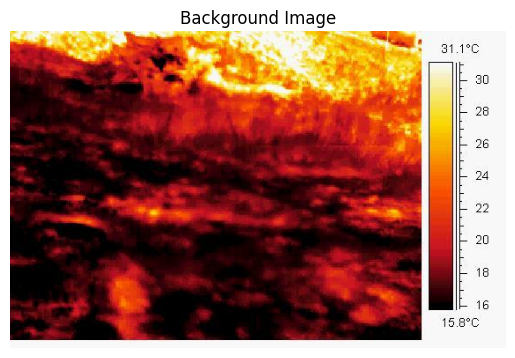

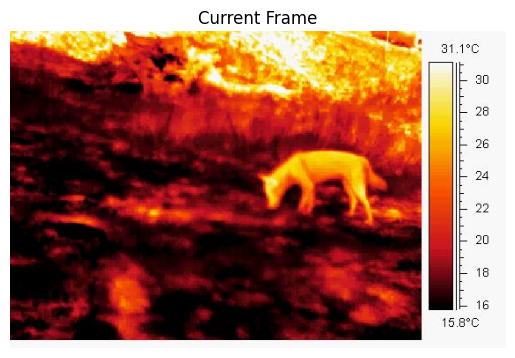

In [2]:
# --------------------------------------------------
# Load and display images
# --------------------------------------------------
backgroundImg = cv2.imread('DINGO3_Background.jpg')
dingoImg = cv2.imread('DINGO3_Frame0.jpg')

# Convert BGR -> RGB for display
backgroundImg = cv2.cvtColor(backgroundImg, cv2.COLOR_BGR2RGB)
dingoImg = cv2.cvtColor(dingoImg, cv2.COLOR_BGR2RGB)

# plot images
plt.figure(1)
plt.imshow(backgroundImg)
plt.title("Background Image")
plt.axis('off')

plt.figure(2)
plt.imshow(dingoImg)
plt.title("Current Frame")
plt.axis('off')



In [3]:
# --------------------------------------------------
# Compute difference image
# (convert to int16 to avoid uint8 overflow)
# --------------------------------------------------
diffImg = dingoImg.astype(np.int16) - backgroundImg.astype(np.int16)


In [4]:
# --------------------------------------------------
# Find min and max pixel values (scaled to 0–1)
# --------------------------------------------------
minPixelValue = diffImg.min(axis=(0, 1)) / 255.0
maxPixelValue = diffImg.max(axis=(0, 1)) / 255.0

print("Min Pixel Value for Red, Green, Blue channels:")
print(minPixelValue)

print("Max Pixel Value for Red, Green, Blue channels:")
print(maxPixelValue)


Min Pixel Value for Red, Green, Blue channels:
[-0.23529412 -0.13333333 -0.18431373]
Max Pixel Value for Red, Green, Blue channels:
[0.97254902 0.96078431 0.61960784]


(np.float64(-0.5), np.float64(563.5), np.float64(359.5), np.float64(-0.5))

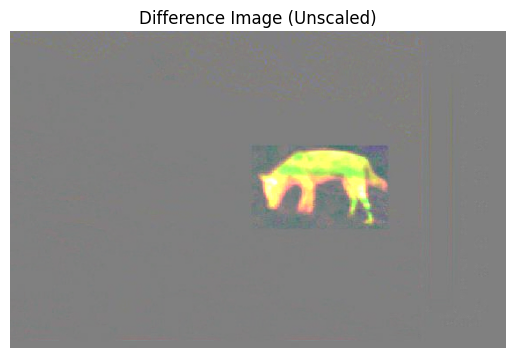

In [5]:
# --------------------------------------------------
# Display difference image without rescaling
# (shift to visible range for plotting)
# --------------------------------------------------
plt.figure(3)
plt.imshow(np.clip(diffImg + 128, 0, 255).astype(np.uint8))
plt.title("Difference Image (Unscaled)")
plt.axis('off')

(np.float64(-0.5), np.float64(563.5), np.float64(359.5), np.float64(-0.5))

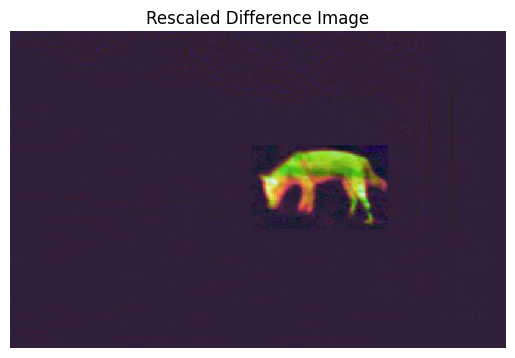

In [6]:
# --------------------------------------------------
# Rescale intensity
# --------------------------------------------------
rescaledDiffImg = np.zeros_like(diffImg, dtype=np.float32)

for c in range(3):
    min_val = diffImg[:, :, c].min()
    max_val = diffImg[:, :, c].max()

    rescaledDiffImg[:, :, c] = (
        (diffImg[:, :, c] - min_val) /
        (max_val - min_val + 1e-6)
    ) * 255

rescaledDiffImg = np.clip(rescaledDiffImg, 0, 255).astype(np.uint8)

plt.figure(4)
plt.imshow(rescaledDiffImg)
plt.title("Rescaled Difference Image")
plt.axis('off')



(np.float64(-0.5), np.float64(563.5), np.float64(359.5), np.float64(-0.5))

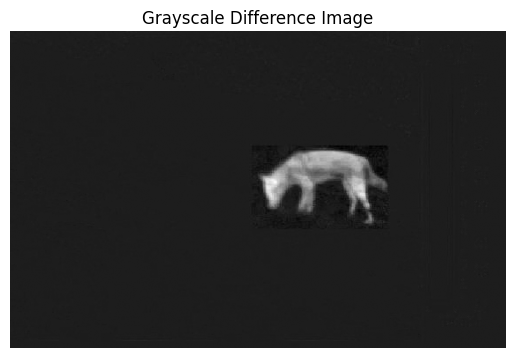

In [7]:
# --------------------------------------------------
# Convert to grayscale
# --------------------------------------------------
greyDiffImg = cv2.cvtColor(rescaledDiffImg, cv2.COLOR_RGB2GRAY)

plt.figure(5)
plt.imshow(greyDiffImg, cmap='gray')
plt.title("Grayscale Difference Image")
plt.axis('off')

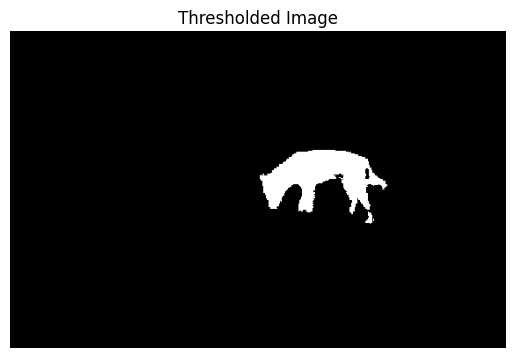

In [8]:
# --------------------------------------------------
# Threshold image (experiment with threshold value)
# --------------------------------------------------
threshold_value = int(0.3 * 255)

_, thresholdedImg = cv2.threshold(
    greyDiffImg,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(6)
plt.imshow(thresholdedImg, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')

plt.show()

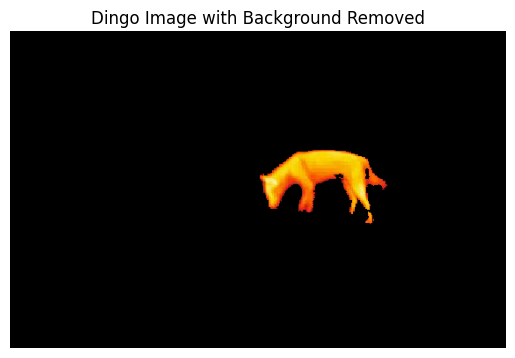

In [13]:
dingoImgNoBackground = cv2.bitwise_and(dingoImg, dingoImg, mask=thresholdedImg)

plt.figure(7)
plt.imshow(dingoImgNoBackground)
plt.title("Dingo Image with Background Removed")
plt.axis('off')
plt.show()

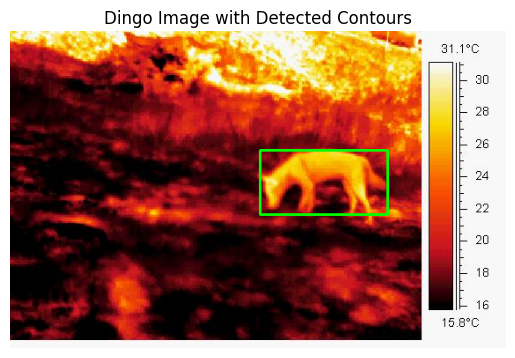

In [18]:
# Draw box around detected dingo
contours, _ = cv2.findContours(thresholdedImg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for contour in contours:
    if cv2.contourArea(contour) > 500:  # Filter small contours
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(dingoImg, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(8)
plt.imshow(dingoImg)
plt.title("Dingo Image with Detected Contours")
plt.axis('off')
plt.show()